# Poverty Maps (XGBoost Regression)

Sources
- https://www.kaggle.com/felipefiorini/xgboost-hyper-parameter-tuning
- https://machinelearningmastery.com/xgboost-for-imbalanced-classification/ (check for better results?)


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ln -s /content/drive/MyDrive/Colab\ Notebooks/SES-Inference /mydrive

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor
from xgboost import XGBRFRegressor
from xgboost import plot_importance
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.impute import SimpleImputer

import os

In [ ]:
import sys

sys.path.append('/mydrive/libs/')
%set_env PYTHONPATH=/env/python:/mydrive/libs/

%load_ext autoreload
%autoreload 2

from utils import ios
from utils import viz
from ses.features import SESFeatures

env: PYTHONPATH=/env/python:/mydrive/libs/
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Constants

In [ ]:
country = {'SL':'Sierra Leone', 'UG':'Uganda'}
code = 'SL'

In [ ]:
ROOT = '/mydrive/data/{}/results'.format(country[code])
TRAIN_TYPE = '2019' # 2016, 2019 (SL), 2018 (UG), 2016-2018 (UG), 2016-2019 (SL)
VAL = False

cols_to_not_include = ["DHSCC","DHSYEAR","DHSCLUST","URBAN_RURA","LATNUM","LONGNUM","SOURCE","ALT_GPS","ALT_DEM","DATUM","mean_iwi",'lat','lon','nodeid']

FN_PPLACES = ''
ROOT

# FN_DHS = '/mydrive/data/{}/results/DHS2016_MIS2018_iwi_cluster_NTLL_cells_population_OSM.csv'
# FN_MODEL = "/mydrive/data/Uganda/results/DHS2016_iwi_cluster_NTLL_cells_population_OSM.model"

'/mydrive/data/Sierra Leone/results'

## Training model on DHS data

### Loading the data

In [ ]:
ses = SESFeatures()
df_data = ses.load_data(ROOT, validate=VAL)
df_data.head()

,DHSCC,DHSYEAR,DHSCLUST,URBAN_RURA,LATNUM,LONGNUM,SOURCE,ALT_GPS,ALT_DEM,DATUM,mean_iwi,SES,distance_closest_cell,cells_in_1.6km,cells_in_2.0km,cells_in_5.0km,cells_in_10.0km,towers_in_1.6km,towers_in_2.0km,towers_in_5.0km,towers_in_10.0km,distance_closest_tile,population_closest_tile,population_in_1.6km,population_in_2.0km,population_in_5.0km,population_in_10.0km,NTLL_1.6km_min,NTLL_1.6km_max,NTLL_1.6km_mean,NTLL_1.6km_median,NTLL_1.6km_l3_mean,NTLL_1.6km_u3_mean,NTLL_1.6km_rad_gte_10.0_area,NTLL_1.6km_rad_gte_10.0_pixels,NTLL_1.6km_rad_gte_10.0_sum_rad,NTLL_2.0km_min,NTLL_2.0km_max,NTLL_2.0km_mean,NTLL_2.0km_median,...,FBMV_WPR,FBMV_PR,FBMV_dist,FBM_frequent_traveler,FBM_small_business_owner,FBM_commuter,FBM_lives_abroad,FBM_frequent_int_traveler,FBM_network_2G,FBM_network_3G,FBM_network_4G,FBM_feature_phone,FBM_old_device_os,FBM_mobile_access,FBM_browser_access,FBM_smartphone_tablet,FBM_wifi,FBM_tech_early_adopter,FBM_returned_travel_1week,FBM_away_from_home,FBM_engaged,FBM_ind_gov,FBM_ind_business,FBM_ind_legal,FBM_ind_it,FBM_device_motorola,FBM_device_amazon,FBM_device_nokia,FBM_device_microsoft,FBM_os_ios,FBM_os_android,FBM_os_windows,FBM_os_windows_desktop,FBM_os_windows_phone,FBM_highschool,FBM_bachelor,FBM_master,FBM_professional,FBM_phd,FBM_casino
0,SL,2016,1,2,7.886692,-10.621199,GPS,213.0,313.0,WGS84,9.380,poor,22377.933013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1230.267866,25.951703,0.000000,0.000000,233.565331,4708.640859,0.000208,0.068138,0.032545,0.033994,0.017199,0.047006,0.0,0.0,0.0,0.000208,0.068138,0.033028,0.034290,...,0.002112,0.002142,17440.967991,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
1,SL,2016,2,2,7.816980,-10.923481,GPS,191.0,175.0,WGS84,16.630,upper_middle,19947.605475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,389.974008,22.220014,644.380394,644.380394,2844.161739,8602.876948,0.028221,0.103269,0.066592,0.067560,0.048828,0.082564,0.0,0.0,0.0,0.028221,0.103269,0.064956,0.065289,...,0.003705,0.003492,15222.593398,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
2,SL,2016,3,2,7.886167,-10.885893,GPS,178.0,178.0,WGS84,10.405,poor,11781.187021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,475.349744,22.220014,333.300204,333.300204,4110.702514,12150.389127,0.025167,0.112642,0.070448,0.068245,0.048377,0.092932,0.0,0.0,0.0,0.025167,0.112642,0.068997,0.068245,...,0.002112,0.002142,9674.255854,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
3,SL,2016,4,2,8.371248,-10.382698,GPS,383.0,372.0,WGS84,13.525,lower_middle,22162.598212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,298.110684,22.480804,359.692857,359.692857,2691.371680,17913.836826,0.026151,0.100974,0.063029,0.059750,0.040614,0.085981,0.0,0.0,0.0,0.017220,0.100974,0.059813,0.056869,...,0.002112,0.002142,2405.930409,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
4,SL,2016,5,2,8.452606,-10.319713,GPS,408.0,453.0,WGS84,12.180,lower_middle,32999.016388,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,645.839127,16.233972,308.445459,1201.313891,12824.837488,21867.159616,0.018828,0.206288,0.069350,0.066081,0.041539,0.100739,0.0,0.0,0.0,0.018828,0.538011,0.072840,0.064862,...,0.002112,0.002142,2281.967537,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,100

#### Descriptive analysis (viz)

In [ ]:
y = 'mean_iwi'
x = 'population_in_1.6km'
hue = 'URBAN_RURA'

viz.plot_data_simple(df_data, x, y, hue, False)

In [ ]:
y = 'mean_iwi'
cols = [c for c in df_data.columns if c not in cols_to_not_include]
hue = 'URBAN_RURA'
viz.plot_data_multiple(df_data, y, cols, hue, nc=6)


### Pre-processing

In [ ]:
### are there nulls?
tmp = df_data.columns[df_data.isna().any()].tolist()
print(tmp)
if len(tmp) > 0:
  tmp2 = df_data[df_data.isna().any(axis=1)]
  print(tmp2)
  print(tmp2.shape)
  df_data = df_data.fillna(0)
  tmp = df_data.columns[df_data.isna().any()].tolist()
  print(tmp)

[]


In [ ]:
### binary
df_data.loc[:,'URBAN_RURA'] = df_data.URBAN_RURA.apply(lambda c: int(c==2))
df_data.URBAN_RURA.unique()

array([1, 0])

In [ ]:
df_data.groupby("DHSYEAR").size()

DHSYEAR
2016    336
2019    557
dtype: int64

In [ ]:
print(TRAIN_TYPE)

if TRAIN_TYPE == 'all':
  # all years
  train = df_data.sample(frac = 0.7)
  test = df_data.drop(train.index)
elif TRAIN_TYPE == '{}-{}'.format(df_data.DHSYEAR.min(), df_data.DHSYEAR.max()):
  # train on earlier, test on later
  train = df_data.query("DHSYEAR==2016").copy()
  test = df_data.query("DHSYEAR!=2016").copy()
elif TRAIN_TYPE in [str(df_data.DHSYEAR.min()), str(df_data.DHSYEAR.max())]: 
  # train and test on 1 year
  tmp = df_data.query("DHSYEAR=={}".format(TRAIN_TYPE)).copy()
  train = tmp.sample(frac = 0.8)
  test = tmp.drop(train.index)

2019


In [ ]:
X = train.drop(cols_to_not_include + ['SES'], axis=1)
y = train['mean_iwi']

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.20,random_state=0)
X_train.shape, X_val.shape

((356, 151), (90, 151))

### XGBoost hyper-parameter tunning

In [ ]:
def hyperParameterTuning(X_train, y_train):
    param_tuning = {
        'learning_rate': [0.0001, 0.001, 0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
        'max_depth': [3, 4, 5, 6, 7],
        'min_child_weight': [1, 3, 5, 7],
        'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'n_estimators' : [50, 100, 150, 200, 250, 300, 350],
        'objective': ['reg:squarederror']
    }

    xgb_model = XGBRegressor()

    gsearch = GridSearchCV(estimator = xgb_model,
                           param_grid = param_tuning,
                           cv = 5,
                           n_jobs = 10,
                           verbose = 1)

    gsearch.fit(X_train,y_train)

    return gsearch.best_params_

In [ ]:
xgb_best_model = hyperParameterTuning(X_train, y_train)
# Fitting 5 folds for each of 12600 candidates, totalling 63000 fits
# RAW
# 339.2min finished -> 5.6 hours UG
# 217.2min finished -> 3.6 hours SL
# VIIRS NORM

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  40 tasks      | elapsed:    1.1s
[Parallel(n_jobs=10)]: Done 340 tasks      | elapsed:    9.9s
[Parallel(n_jobs=10)]: Done 840 tasks      | elapsed:   27.0s
[Parallel(n_jobs=10)]: Done 1540 tasks      | elapsed:   48.7s
[Parallel(n_jobs=10)]: Done 2440 tasks      | elapsed:  1.3min
[Parallel(n_jobs=10)]: Done 3540 tasks      | elapsed:  1.9min
[Parallel(n_jobs=10)]: Done 4280 tasks      | elapsed:  2.4min
[Parallel(n_jobs=10)]: Done 5030 tasks      | elapsed:  2.9min
[Parallel(n_jobs=10)]: Done 5880 tasks      | elapsed:  3.5min
[Parallel(n_jobs=10)]: Done 6830 tasks      | elapsed:  4.1min
[Parallel(n_jobs=10)]: Done 7880 tasks      | elapsed:  4.8min
[Parallel(n_jobs=10)]: Done 8640 out of 8640 | elapsed:  5.3min finished


In [ ]:
xgb_best_model

{'colsample_bytree': 0.5,
 'learning_rate': 0.1,
 'max_depth': 2,
 'min_child_weight': 7,
 'n_estimators': 50,
 'objective': 'reg:squarederror',
 'subsample': 0.3}

#### Best Fit

In [ ]:
xgb_model = XGBRegressor(
        objective = xgb_best_model['objective'],
        colsample_bytree = xgb_best_model['colsample_bytree'],
        learning_rate = xgb_best_model['learning_rate'],
        max_depth = xgb_best_model['max_depth'],
        min_child_weight = xgb_best_model['min_child_weight'],
        n_estimators = xgb_best_model['n_estimators'],
        subsample = xgb_best_model['subsample'])

%time xgb_model.fit(X_train, y_train, early_stopping_rounds=50, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = xgb_model.predict(X_val)

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)

print("MAE: ", mae_xgb)
print("R2: ", r2_xgb)

CPU times: user 90.1 ms, sys: 856 µs, total: 91 ms
Wall time: 90.9 ms
MAE:  3.9382066604301857
R2:  0.8600159818286364


In [ ]:
fn = "raw_features" if not VAL else "viirs_norm"
fn = "{}_{}.model".format(fn, TRAIN_TYPE)
print(fn)
fn = os.path.join(ROOT,fn)
pickle.dump(xgb_model, open(fn, 'wb'))

raw_features_2019.model


#### Feature importance

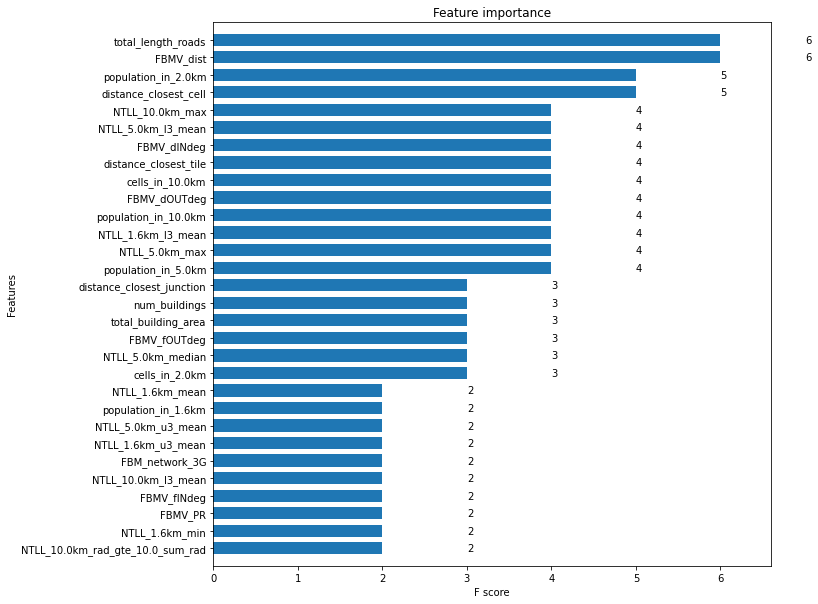

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_importance(xgb_model, max_num_features=30, height=0.7, ax=ax)
ax.grid(False)
plt.show()
plt.close()

### Results

#### Validation

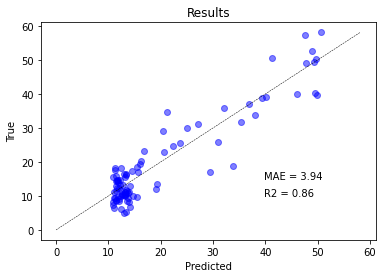

In [ ]:
#Plot Real vs Predict
viz.plot_pred_true(pred=y_pred_xgb, true=y_val, metric={'MAE':mae_xgb, 'R2':r2_xgb})

#### Test

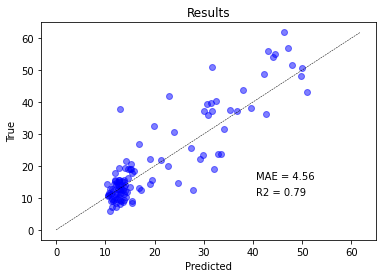

In [ ]:
X_test = test.drop(cols_to_not_include + ['SES'], axis=1)
y_test = test['mean_iwi']

y_pred_test = xgb_model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

#Plot Real vs Predict
viz.plot_pred_true(pred=y_pred_test, true=y_test, metric={'MAE':mae_test, 'R2':r2_test})

## Prediction on Populated places

In [ ]:
df_pplaces = ios.load_csv(FN_PPLACES)

In [ ]:
xgb_model = pickle.load(open(FN_MODEL, 'rb'))
xgb_model

In [ ]:
X_test = df_pplaces.drop(['osmid','lat','lon'], axis=1)
y_pred_test = xgb_model.predict(X_test)

#Plot Real vs Predict
viz.plot_pred_true(pred=y_pred_test, true=y_test)